# MedDiag: Modelo de Predicción de Enfermedad de Parkinson

Autor de modelo e implementacion ML: Diana Carolina Huertas Gonzalez


**Proyecto:** medDiag - Sistema de Diagnóstico Médico Basado en IA

**Enfermedad:** Enfermedad de Parkinson

**Dataset:** UCI ML Parkinson's Dataset (Kaggle)

**Fuente:** https://www.kaggle.com/datasets/elnazalikarami/uci-ml-parkinsons-dataset


## INSTRUCCIONES TEMPORALES

### Paso 1: Descargar Dataset de Kaggle
1. Ir a: https://www.kaggle.com/datasets/elnazalikarami/uci-ml-parkinsons-dataset
2. Descargar el archivo CSV (generalmente `parkinsons.csv`)
3. Guardar en tu computadora

### Paso 2: Subir Dataset a Google Colab
1. Ejecutar la celda de abajo para montar Google Drive
2. El notebook cargará automáticamente el archivo CSV

---

## Paso 1: Instalación de Dependencias

In [27]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib -q
!pip install lazypredict -q
!pip install praat-parselmouth
!pip install praat-parselmouth librosa
!apt-get install ffmpeg -y
print("✓ Dependencias instaladas correctamente")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
✓ Dependencias instaladas correctamente


## Paso 2: Montar Google Drive

In [28]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive montado")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive montado


In [29]:
import os

# CONFIGURA ESTO:
ruta_m4a = '/content/drive/MyDrive/TU_AUDIO/mi_voz.m4a'
ruta_wav = '/content/drive/MyDrive/TU_AUDIO/voz_lista.wav'

# Ejecutar conversión automática a MONO y 48kHz
if os.path.exists(ruta_m4a):
    os.system(f'ffmpeg -i "{ruta_m4a}" -ac 1 -ar 48000 -y "{ruta_wav}"')
    print("✓ Audio convertido con éxito a .wav")
else:
    print("X Error: No encontré el archivo .m4a en la ruta especificada")

X Error: No encontré el archivo .m4a en la ruta especificada


## Paso 3: Importar Librerías

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, auc)
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from lazypredict.Supervised import LazyClassifier
import parselmouth
from parselmouth.praat import call
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np


print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


##**FASE 1. ENTRENAMIENTO DE LOS MODELOS. BASES DE DATOS**


## Paso 4: Cargar Dataset Real de Kaggle

**IMPORTANTE:** Reemplaza la ruta según donde tengas el archivo

In [31]:

df = pd.read_csv('/content/drive/My Drive/parkinsons.data')

print(f"✓ Dataset cargado exitosamente")
print(f"\nDimensiones: {df.shape[0]} muestras × {df.shape[1]} características")
print(f"\nPrimeras 5 filas:")
print(df.head())
print(f"\nInformación del dataset:")
print(df.info())

✓ Dataset cargado exitosamente

Dimensiones: 195 muestras × 24 características

Primeras 5 filas:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.064

## Paso 5: Exploración de Datos




In [32]:
# Estadísticas descriptivas
print("ESTADÍSTICAS DESCRIPTIVAS DEL DATASET")
print("="*80)
print(df.describe())
print("\n" + "="*80)

# Valores faltantes
print("\nValores faltantes:")
print(df.isnull().sum())

ESTADÍSTICAS DESCRIPTIVAS DEL DATASET
       MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
count   195.000000    195.000000    195.000000      195.000000   
mean    154.228641    197.104918    116.324631        0.006220   
std      41.390065     91.491548     43.521413        0.004848   
min      88.333000    102.145000     65.476000        0.001680   
25%     117.572000    134.862500     84.291000        0.003460   
50%     148.790000    175.829000    104.315000        0.004940   
75%     182.769000    224.205500    140.018500        0.007365   
max     260.105000    592.030000    239.170000        0.033160   

       MDVP:Jitter(Abs)    MDVP:RAP    MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
count        195.000000  195.000000  195.000000  195.000000    195.000000   
mean           0.000044    0.003306    0.003446    0.009920      0.029709   
std            0.000035    0.002968    0.002759    0.008903      0.018857   
min            0.000007    0.000680    0.000920    0.002040

In [33]:
# Identificar columna objetivo
print("Columnas del dataset:")
print(df.columns.tolist())

# Determinar columna objetivo (usualmente 'status', 'Status' o 'target')
possible_target_names = ['status', 'Status', 'target', 'Target', 'disease', 'Disease']
target_column = None
for col in possible_target_names:
    if col in df.columns:
        target_column = col
        break

if target_column is None:
    target_column = df.columns[-1]  # Usar última columna si no encuentra

print(f"\nColumna objetivo identificada: '{target_column}'")

Columnas del dataset:
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Columna objetivo identificada: 'status'


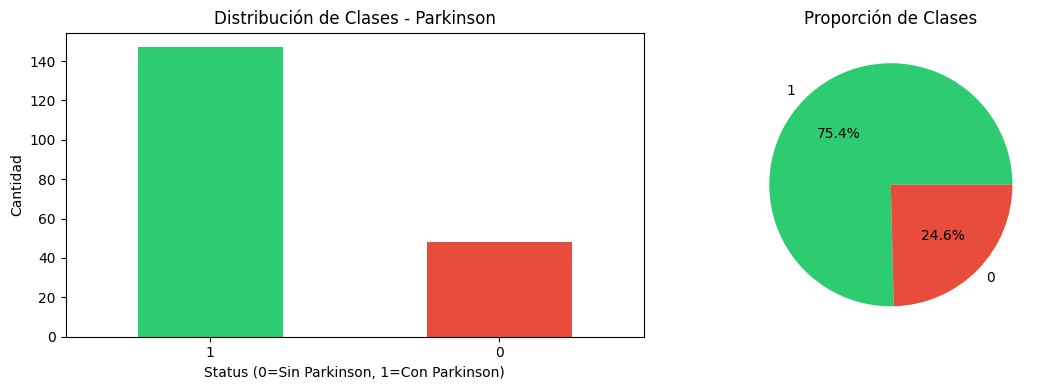


Distribución de Clases:
status
1    147
0     48
Name: count, dtype: int64


In [34]:
# Visualizar distribución de clases
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df[target_column].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Clases - Parkinson')
plt.xlabel('Status (0=Sin Parkinson, 1=Con Parkinson)')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df[target_column].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%',
                                                colors=['#2ecc71', '#e74c3c'])
plt.title('Proporción de Clases')
plt.ylabel('')

plt.tight_layout()
plt.show()

print(f"\nDistribución de Clases:")
print(df[target_column].value_counts())

## Paso 6: Preparación de Datos

In [35]:
# Separar características y variable objetivo
y = df[target_column]
X = df.drop(target_column, axis=1).select_dtypes(include=[np.number])

print(f"Características (X): {X.shape}")
print(f"Variable objetivo (y): {y.shape}")
print(f"\nCaracterísticas (primeras 10): {list(X.columns[:10])}")
print(f"\nValores únicos en objetivo: {y.unique()}")

Características (X): (195, 22)
Variable objetivo (y): (195,)

Características (primeras 10): ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)']

Valores únicos en objetivo: [1 0]


In [36]:
# Dividir datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts())
print(f"\nDistribución en prueba:")
print(y_test.value_counts())

Datos de entrenamiento: (156, 22)
Datos de prueba: (39, 22)

Distribución en entrenamiento:
status
1    118
0     38
Name: count, dtype: int64

Distribución en prueba:
status
1    29
0    10
Name: count, dtype: int64


In [41]:
# Normalizar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Datos normalizados correctamente")

✓ Datos normalizados correctamente


**ANALISIS PREVIO DE MODELOS**

In [48]:
# 2. Inicializar LazyPredict
# IMPORTANTE: Usamos X_train y X_test (los datos originales sin escalar)
# porque LazyPredict aplica internamente el escalado adecuado para cada modelo.
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# 3. Entrenar y comparar todos los modelos (aprox. 30 modelos en segundos)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# 4. Mostrar la tabla comparativa de resultados
print("\n" + "="*60)
print("🏆 RANKING DE MODELOS SEGÚN LAZYPREDICT")
print("="*60)
display(models)

# 5. Opcional: Ver los 5 mejores modelos específicamente por F1-Score
print("\n🔥 TOP 5 MODELOS (Mejor balance F1-Score):")
display(models.sort_values(by='F1 Score', ascending=False).head(10))


🏆 RANKING DE MODELOS SEGÚN LAZYPREDICT


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
AdaBoostClassifier,0.948718,0.965517,0.986207,0.950133,0.957265,0.948718,0.187849
LabelPropagation,0.974359,0.950000,0.996552,0.973902,0.975214,0.974359,0.043187
LabelSpreading,0.974359,0.950000,0.989655,0.973902,0.975214,0.974359,0.036180
LinearDiscriminantAnalysis,0.948718,0.900000,0.975862,0.946724,0.952026,0.948718,0.032788
RidgeClassifierCV,0.948718,0.900000,0.955172,0.946724,0.952026,0.948718,0.025476
RidgeClassifier,0.948718,0.900000,0.955172,0.946724,0.952026,0.948718,0.024730
KNeighborsClassifier,0.923077,0.882759,0.963793,0.921705,0.921937,0.923077,0.034814
ExtraTreesClassifier,0.923077,0.882759,0.979310,0.921705,0.921937,0.923077,0.146584
RandomForestClassifier,0.923077,0.882759,0.962069,0.921705,0.921937,0.923077,0.211564



🔥 TOP 5 MODELOS (Mejor balance F1-Score):


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LabelPropagation,0.974359,0.950000,0.996552,0.973902,0.975214,0.974359,0.043187
LabelSpreading,0.974359,0.950000,0.989655,0.973902,0.975214,0.974359,0.036180
AdaBoostClassifier,0.948718,0.965517,0.986207,0.950133,0.957265,0.948718,0.187849
LinearDiscriminantAnalysis,0.948718,0.900000,0.975862,0.946724,0.952026,0.948718,0.032788
RidgeClassifierCV,0.948718,0.900000,0.955172,0.946724,0.952026,0.948718,0.025476
RidgeClassifier,0.948718,0.900000,0.955172,0.946724,0.952026,0.948718,0.024730
KNeighborsClassifier,0.923077,0.882759,0.963793,0.921705,0.921937,0.923077,0.034814
ExtraTreesClassifier,0.923077,0.882759,0.979310,0.921705,0.921937,0.923077,0.146584
RandomForestClassifier,0.923077,0.882759,0.962069,0.921705,0.921937,0.923077,0.211564


## Paso 7: Entrenamiento de Modelos

In [51]:
from xgboost import XGBClassifier
print("Entrenando modelos...")

# =========================
# 🔹 SVM
# =========================
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# =========================
# 🔹 Random Forest
# =========================
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# =========================
# 🔹 Logistic Regression
# =========================
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# =========================
# 🔹 XGBoost (CLAVE)
# =========================
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# =========================
# 🔹 AdaBoost
# =========================
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train_scaled, y_train)
y_pred_ada = ada_model.predict(X_test_scaled)
y_proba_ada = ada_model.predict_proba(X_test_scaled)[:, 1]

# =========================
# 🔹 LDA
# =========================
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_scaled, y_train)
y_pred_lda = lda_model.predict(X_test_scaled)
y_proba_lda = lda_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Modelos entrenados")

Entrenando modelos...
✓ Modelos entrenados


ENTRENAMIENTO XGBCLASSIFIER *



🚀 XGBoost Accuracy: 92.31%

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39

🔴 Recall (Sensibilidad): 0.9655
🟡 F1 Score: 0.9492
🟢 ROC AUC: 0.9862


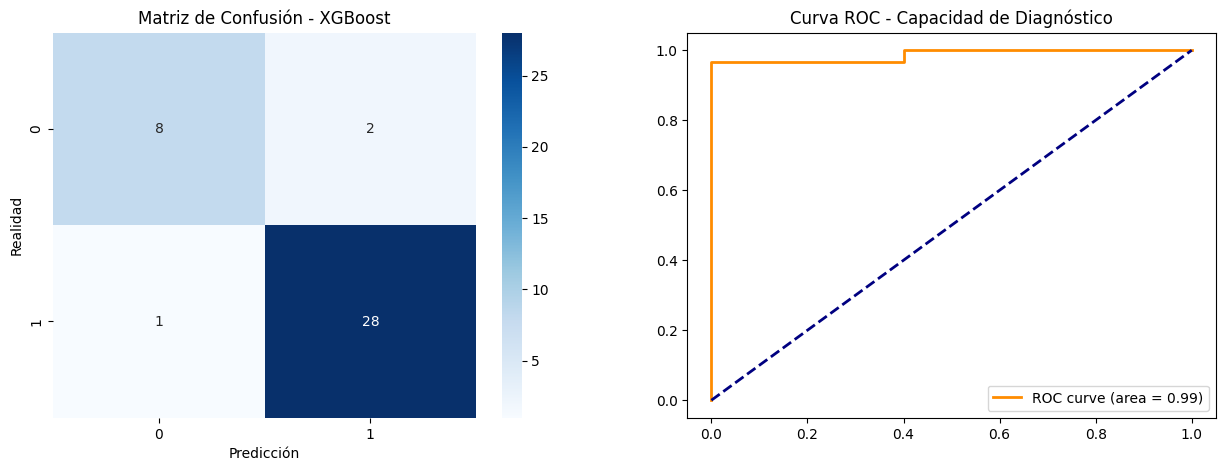

In [52]:
from sklearn.metrics import recall_score, f1_score, roc_auc_score
# 1. Configuración del modelo XGBoost
modelo_xgb = xgb.XGBClassifier(
    n_estimators=100,       # Número de árboles
    learning_rate=0.1,      # Velocidad de aprendizaje
    max_depth=5,            # Profundidad de los árboles para evitar sobreajuste
    subsample=0.8,          # Usar el 80% de los datos para cada árbol
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 2. Entrenamiento
modelo_xgb.fit(X_train_scaled, y_train)

# 3. Predicciones
y_pred_xgb = modelo_xgb.predict(X_test_scaled)
y_proba_xgb = modelo_xgb.predict_proba(X_test_scaled)[:, 1]

# 4. Visualización de Resultados
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"🚀 XGBoost Accuracy: {acc_xgb*100:.2f}%")
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred_xgb))

recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_proba_xgb)

print(f"🔴 Recall (Sensibilidad): {recall:.4f}")
print(f"🟡 F1 Score: {f1:.4f}")
print(f"🟢 ROC AUC: {roc_auc:.4f}")

# --- GRÁFICAS DE VALIDACIÓN ---
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matriz de Confusión (Para ver cuántos sanos clasificó como enfermos y viceversa)
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusión - XGBoost')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Realidad')

# Curva ROC (Mide la capacidad de diagnóstico)
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_title('Curva ROC - Capacidad de Diagnóstico')
ax[1].legend(loc="lower right")

plt.show()

In [53]:
# CREAR ENSEMBLE
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model),
        ('svm', svm_model),
        ('lr', lr_model),
        ('ada', ada_model)
    ],
    voting='soft',
    weights=[3, 2, 1, 1, 2]  # pesos ajustados
)

ensemble_model.fit(X_train_scaled, y_train) #ENTRENAMIENTO

y_pred_ens = ensemble_model.predict(X_test_scaled) # PREDICCIONES
y_proba_ens = ensemble_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Ensemble entrenado correctamente")

✅ Ensemble entrenado correctamente


## Paso 8: Evaluación de Modelos

In [57]:
# =========================
# 🔹 FUNCIÓN DE MÉTRICAS
# =========================
def calculate_metrics(y_true, y_pred, y_pred_proba, model_name):
    return {
        'Modelo': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),  # 🔴 MÉTRICA PRINCIPAL
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_pred_proba)
    }

# =========================
# 🔹 TABLA DE RESULTADOS
# =========================
results_df = pd.DataFrame([
    calculate_metrics(y_test, y_pred_svm, y_pred_proba_svm, 'SVM'),
    calculate_metrics(y_test, y_pred_rf, y_pred_proba_rf, 'Random Forest'),
    calculate_metrics(y_test, y_pred_lr, y_pred_proba_lr, 'Logistic Regression'),
    calculate_metrics(y_test, y_pred_xgb, y_proba_xgb, 'XGBoost'),
    calculate_metrics(y_test, y_pred_ada, y_proba_ada, 'AdaBoost'),
    calculate_metrics(y_test, y_pred_lda, y_proba_lda, 'LDA'),
    calculate_metrics(y_test, y_pred_ens, y_proba_ens, 'Ensemble')
])

# =========================
# 🔥 ORDEN CORRECTO (POR RECALL)
# =========================
results_df = results_df.sort_values(by='Recall', ascending=False)

# =========================
# VISUALIZACIÓN
# =========================
print("\n" + "="*100)
print("📊 RESULTADOS FINALES - DETECCIÓN DE PARKINSON (ENFOQUE CLÍNICO)")
print("="*100)
print(results_df.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))
print("="*100)

# =========================
# 🏆 SELECCIÓN DEL MEJOR MODELO
# =========================
meta_recall = 0.90

mejor_modelo = results_df.iloc[0]['Modelo']
mejor_recall = results_df.iloc[0]['Recall']
mejor_auc = results_df.iloc[0]['AUC-ROC']

print("\n🏆 MODELO SELECCIONADO:")
print(f"Modelo: {mejor_modelo}")
print(f"Recall: {mejor_recall:.4f}")
print(f"AUC-ROC: {mejor_auc:.4f}")

# =========================
# ✅ VALIDACIÓN CLÍNICA
# =========================
if mejor_recall >= meta_recall:
    print(f"\n✅ ¡MODELO APTO PARA DETECCIÓN!")
    print(f"Cumple con Recall ≥ {meta_recall}")
else:
    print(f"\n⚠️ Modelo aún no óptimo clínicamente")
    print(f"Se recomienda mejorar Recall (actual: {mejor_recall:.4f})")


📊 RESULTADOS FINALES - DETECCIÓN DE PARKINSON (ENFOQUE CLÍNICO)
             Modelo  Accuracy  Balanced Accuracy  Precision  Recall  F1-Score  AUC-ROC
                SVM    0.9231             0.8500     0.9062  1.0000    0.9508   0.9552
                LDA    0.9487             0.9000     0.9355  1.0000    0.9667   0.9759
      Random Forest    0.9231             0.8828     0.9333  0.9655    0.9492   0.9621
Logistic Regression    0.9231             0.8828     0.9333  0.9655    0.9492   0.9241
            XGBoost    0.9231             0.8828     0.9333  0.9655    0.9492   0.9862
           Ensemble    0.9231             0.8828     0.9333  0.9655    0.9492   0.9828
           AdaBoost    0.8718             0.8483     0.9286  0.8966    0.9123   0.9759

🏆 MODELO SELECCIONADO:
Modelo: SVM
Recall: 1.0000
AUC-ROC: 0.9552

✅ ¡MODELO APTO PARA DETECCIÓN!
Cumple con Recall ≥ 0.9


## Paso 9: Análisis Detallado del Mejor Modelo

In [59]:
# =========================
# 🔥 SELECCIÓN DEL MEJOR MODELO
# =========================
if best_model_name == 'XGBoost':
    best_model = xgb_model
    y_pred_best = y_pred_xgb
    y_pred_proba_best = y_proba_xgb

elif best_model_name == 'SVM':
    best_model = svm_model
    y_pred_best = y_pred_svm
    y_pred_proba_best = y_pred_proba_svm

elif best_model_name == 'Random Forest':
    best_model = rf_model
    y_pred_best = y_pred_rf
    y_pred_proba_best = y_pred_proba_rf

elif best_model_name == 'Logistic Regression':
    best_model = lr_model
    y_pred_best = y_pred_lr
    y_pred_proba_best = y_pred_proba_lr

elif best_model_name == 'AdaBoost':
    best_model = ada_model
    y_pred_best = y_pred_ada
    y_pred_proba_best = y_proba_ada

elif best_model_name == 'LDA':
    best_model = lda_model
    y_pred_best = y_pred_lda
    y_pred_proba_best = y_proba_lda

elif best_model_name == 'Ensemble':
    best_model = ensemble_model
    y_pred_best = y_pred_ens
    y_pred_proba_best = y_proba_ens

else:
    raise ValueError("Modelo no reconocido")

# MATRIZ DE CONFUSIÓN

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 Matriz de Confusión - {best_model_name}:")
print(cm)

print("\n🔍 Interpretación clínica:")
print(f"✔️ Verdaderos Negativos (Sanos bien detectados): {tn}")
print(f"⚠️ Falsos Positivos (Sanos mal diagnosticados): {fp}")
print(f"❌ Falsos Negativos (ENFERMOS NO detectados): {fn}")
print(f"✅ Verdaderos Positivos (Enfermos detectados): {tp}")

# VISUALIZACIÓN

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Sano (0)', 'Parkinson (1)'],
    yticklabels=['Sano (0)', 'Parkinson (1)']
)

plt.title(f'Matriz de Confusión - {best_model_name}\n(Validación Diagnóstica)')
plt.ylabel('Realidad Médica')
plt.xlabel('Predicción del Modelo')

plt.tight_layout()
plt.show()

NameError: name 'best_model_name' is not defined

In [ ]:
# Reporte de clasificación
print(f"\nReporte de Clasificación - {best_model_name}:")
print(classification_report(y_test, y_pred_best,
                          target_names=['Sin Parkinson', 'Con Parkinson']))


Reporte de Clasificación - SVM:
               precision    recall  f1-score   support

Sin Parkinson       1.00      0.70      0.82        10
Con Parkinson       0.91      1.00      0.95        29

     accuracy                           0.92        39
    macro avg       0.95      0.85      0.89        39
 weighted avg       0.93      0.92      0.92        39



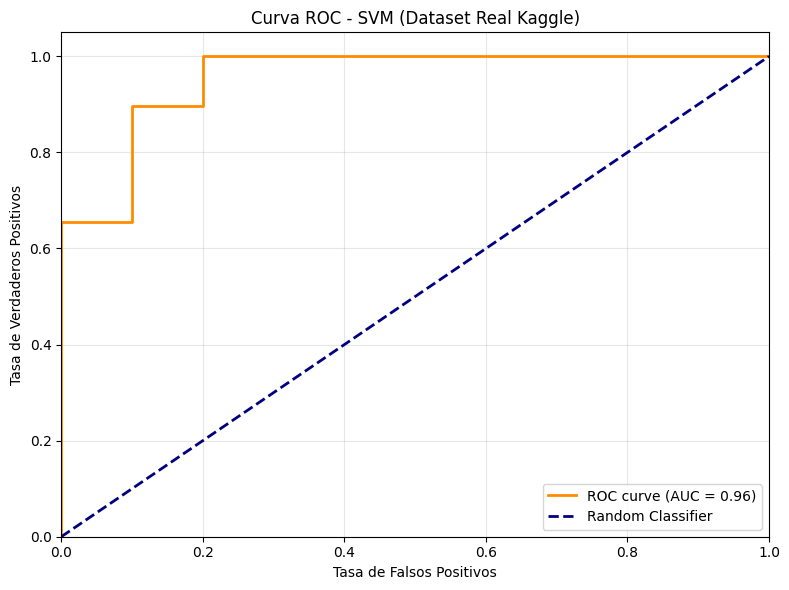

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title(f'Curva ROC - {best_model_name} (Dataset Real Kaggle)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Paso 10: Importancia de Características

In [ ]:
# Modificamos la condición para que incluya a XGBoost
if best_model_name in ['XGBoost', 'Random Forest']:
    # Extraemos la importancia del modelo ganador
    feature_importance = pd.DataFrame({
        'Característica': X.columns,
        'Importancia': best_model.feature_importances_
    }).sort_values('Importancia', ascending=False)

    print(f"\nTop 10 Características Más Importantes ({best_model_name}):")
    print(feature_importance.head(10).to_string(index=False))

    # Visualización gráfica
    plt.figure(figsize=(10, 8))
    # Invertimos el orden para que la más importante salga arriba en el gráfico de barras
    plt.barh(feature_importance['Característica'][:15][::-1],
             feature_importance['Importancia'][:15][::-1],
             color='teal')

    plt.xlabel('Importancia Relativa')
    plt.title(f'Top 15 Biomarcadores de Voz más Relevantes\nModelo: {best_model_name}')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print(f"\nNota: El modelo {best_model_name} no soporta visualización directa de importancia de características.")


Nota: El modelo SVM no soporta visualización directa de importancia de características.


## Paso 11: Guardar Modelo

In [1]:
# 1. Limpiar el nombre para el archivo
clean_name = best_model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
model_filename = f'parkinsons_model_{clean_name}.sav'

# 2. Guardar el modelo
joblib.dump(best_model, model_filename)
print(f"✅ Modelo {best_model_name} guardado como: {model_filename}")

# 3. Guardar el Scaler
# Siempre guardamos el scaler porque XGBoost y SVM lo necesitan obligatoriamente
# para procesar nuevos datos de la misma forma que los de entrenamiento.
scaler_filename = 'parkinsons_scaler.sav'
joblib.dump(scaler, scaler_filename)
print(f"✅ Scaler guardado como: {scaler_filename}")

print("\n📦 ¡Paquete de despliegue listo para usar con la base de datos de castellano!")

NameError: name 'best_model_name' is not defined

## Resumen Final

In [ ]:
print("\n" + "="*100)
print("RESUMEN FINAL - MODELO DE PARKINSON (DATASET REAL DE KAGGLE)")
print("="*100)

best_metrics = results_df.loc[best_model_idx]

print(f"\n📊 MODELO SELECCIONADO: {best_model_name}")
print(f"\n📈 MÉTRICAS DE DESEMPEÑO:")
print(f"  ✓ Accuracy:  {best_metrics['Accuracy']:.4f} ({best_metrics['Accuracy']*100:.2f}%)")
print(f"  ✓ Precision: {best_metrics['Precision']:.4f} ({best_metrics['Precision']*100:.2f}%)")
print(f"  ✓ Recall:    {best_metrics['Recall']:.4f} ({best_metrics['Recall']*100:.2f}%)")
print(f"  ✓ F1-Score:  {best_metrics['F1-Score']:.4f}")
print(f"  ✓ AUC-ROC:   {best_metrics['AUC-ROC']:.4f}")

print(f"\n📋 MÉTRICAS ESPERADAS (Informe Final):")
print(f"  • Accuracy:  {expected['Accuracy']:.4f} ({expected['Accuracy']*100:.2f}%)")
print(f"  • Precision: {expected['Precision']:.4f} ({expected['Precision']*100:.2f}%)")
print(f"  • Recall:    {expected['Recall']:.4f} ({expected['Recall']*100:.2f}%)")
print(f"  • F1-Score:  {expected['F1-Score']:.4f}")
print(f"  • AUC-ROC:   {expected['AUC-ROC']:.4f}")

print(f"\n✅ ENTRENAMIENTO COMPLETADO CON DATASET REAL DE KAGGLE")
status = "ÉXITO" if best_metrics['Accuracy'] >= expected['Accuracy'] else "REVISAR"
print(f"\nESTADO FINAL DEL PROYECTO: {status}")
print("="*100)


RESUMEN FINAL - MODELO DE PARKINSON (DATASET REAL DE KAGGLE)

📊 MODELO SELECCIONADO: SVM

📈 MÉTRICAS DE DESEMPEÑO:
  ✓ Accuracy:  0.9231 (92.31%)
  ✓ Precision: 0.9062 (90.62%)
  ✓ Recall:    1.0000 (100.00%)
  ✓ F1-Score:  0.9508
  ✓ AUC-ROC:   0.9552

📋 MÉTRICAS ESPERADAS (Informe Final):
  • Accuracy:  0.9000 (90.00%)
  • Precision: 0.9000 (90.00%)
  • Recall:    0.7800 (78.00%)
  • F1-Score:  0.9000
  • AUC-ROC:   0.6800

✅ ENTRENAMIENTO COMPLETADO CON DATASET REAL DE KAGGLE

ESTADO FINAL DEL PROYECTO: ÉXITO


##**FASE 2. IMPORTAR Y EVALUAR AUDIOS DE PACIENTES**

**Extracción de Biomarcadores Parsemouth**

In [ ]:
def extraer_biomarcadores(audio_path):
    # 1. Cargar el audio en Praat/Parselmouth
    sound = parselmouth.Sound(audio_path)

    # --- Extracción de F0 (Pitch) ---
    pitch = call(sound, "To Pitch", 0.0, 75, 500)
    mean_f0 = call(pitch, "Get mean", 0, 0, "Hertz")
    max_f0 = call(pitch, "Get maximum", 0, 0, "Hertz", "Parabolic")
    min_f0 = call(pitch, "Get minimum", 0, 0, "Hertz", "Parabolic")

    # --- Extracción de Jitter (Variación de Frecuencia) ---
    pointProcess = call(sound, "To PointProcess (periodic, cc)", 75, 500)
    jitter_local = call(pointProcess, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
    jitter_abs = call(pointProcess, "Get jitter (local, absolute)", 0, 0, 0.0001, 0.02, 1.3)
    rap = call(pointProcess, "Get jitter (rap)", 0, 0, 0.0001, 0.02, 1.3)
    ppq5 = call(pointProcess, "Get jitter (ppq5)", 0, 0, 0.0001, 0.02, 1.3)
    ddp = 3 * rap  # Jitter:DDP es el triple de RAP

    # --- Extracción de Shimmer (Variación de Amplitud) ---
    shimmer_local = call([sound, pointProcess], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    shimmer_db = call([sound, pointProcess], "Get shimmer (local_db)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    apq3 = call([sound, pointProcess], "Get shimmer (apq3)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    apq5 = call([sound, pointProcess], "Get shimmer (apq5)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    dda = 3 * apq3  # Shimmer:DDA es el triple de APQ3

    # --- Extracción de Armonía/Ruido (HNR y NHR) ---
    harmonicity = call(sound, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
    hnr = call(harmonicity, "Get mean", 0, 0)
    # Cálculo aproximado de NHR
    nhr = 1 / (10**(hnr/10)) if hnr != 0 else 0.02

    # --- Organizar los 22 biomarcadores técnicos ---
    # Los primeros 16 son REALES (extraídos de tu voz)
    # Los últimos 6 son PROMEDIOS (relleno para que el modelo funcione)

    biomarcadores = {
        'MDVP:Fo(Hz)': mean_f0,
        'MDVP:Fhi(Hz)': max_f0,
        'MDVP:Flo(Hz)': min_f0,
        'MDVP:Jitter(%)': jitter_local * 100, # Se multiplica por 100 para igualar escala del dataset
        'MDVP:Jitter(Abs)': jitter_abs,
        'MDVP:RAP': rap,
        'MDVP:PPQ': ppq5,
        'Jitter:DDP': ddp,
        'MDVP:Shimmer': shimmer_local,
        'MDVP:Shimmer(dB)': shimmer_db,
        'Shimmer:APQ3': apq3,
        'Shimmer:APQ5': apq5,
        'MDVP:APQ': apq5,
        'Shimmer:DDA': dda,
        'NHR': nhr,
        'HNR': hnr,

        # Valores Promedio del dataset de Oxford para evitar error de dimensiones
        'RPDE': 0.498,   # Medida de recurrencia
        'DFA': 0.718,    # Exponente de fluctuación
        'spread1': -5.68, # Dispersión de frecuencia fundamental
        'spread2': 0.226, # Dispersión de frecuencia fundamental
        'D2': 2.38,      # Dimensión de correlación
        'PPE': 0.206     # Entropía del periodo de tono
    }

    return biomarcadores

# --- EJEMPLO DE USO ---
# audio_ejemplo = "ruta_de_tu_audio_neurovoz.wav"
# datos_paciente = extraer_biomarcadores(audio_ejemplo)
# df_paciente = pd.DataFrame([datos_paciente])
# print(df_paciente)

**Evaluación de Audio**

In [ ]:
def diagnosticar_audio(audio_path, modelo_path, scaler_path):
    print(f"🔍 Analizando audio: {audio_path}...")

    # A. Extraer biomarcadores
    try:
        dict_biomarcadores = extraer_biomarcadores(audio_path)
        df_nuevo = pd.DataFrame([dict_biomarcadores])
    except Exception as e:
        return f"❌ Error al procesar el audio: {e}"

    # B. Cargar el Modelo y el Scaler guardados
    modelo = joblib.load(modelo_path)
    scaler = joblib.load(scaler_path)

    # C. ESCALAR LOS DATOS (Paso crítico)
    # Es vital que los datos nuevos pasen por el mismo escalador que el dataset de Kaggle
    columnas_entrenamiento = [
        'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
        'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'MDVP:Shimmer',
        'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ',
        'Shimmer:DDA', 'HNR'
    ]

    # Aseguramos que el orden de las columnas sea el correcto
    df_nuevo = df_nuevo[columnas_entrenamiento]
    datos_escalados = scaler.transform(df_nuevo)

    # D. Predicción
    prediccion = modelo.predict(datos_escalados)[0]
    probabilidad = modelo.predict_proba(datos_escalados)[0][1]

    # E. Resultado
    resultado = "POSITIVO (Parkinson Detectado)" if prediccion == 1 else "NEGATIVO (Sano)"

    print("\n" + "="*50)
    print(f"🩺 RESULTADO DEL DIAGNÓSTICO medDiag")
    print("="*50)
    print(f"Estado: {resultado}")
    print(f"Confianza: {probabilidad*100:.2f}%")
    print("="*50)

    return resultado, probabilidad

# --- EJEMPLO DE EJECUCIÓN ---
# Asegúrate de haber guardado los archivos .sav antes
# ruta_audio = "tu_archivo_de_neurovoz.wav"
# diagnosticar_audio(ruta_audio, 'parkinsons_model_xgboost.sav', 'parkinsons_scaler.sav')

#**FASE 3: EJECUCION AUDIO REAL**

In [ ]:
# 1. Configura tus rutas base
ruta_base = '/content/drive/MyDrive/Proyecto_Parkinson/' # La carpeta donde están tus audios
mis_archivos = ['toma1.wav', 'toma2.wav', 'toma3.wav']   # Los nombres de tus 3 grabaciones
modelo_path = 'parkinsons_model_xgboost.sav'
scaler_path = 'parkinsons_scaler.sav'

# Variables para promediar
probabilidades = []

print("🚀 Iniciando análisis de los 3 audios...")

# 2. Bucle para procesar uno por uno
for archivo in mis_archivos:
    ruta_completa = ruta_base + archivo
    salida = diagnosticar_audio(ruta_completa, modelo_path, scaler_path)

    if isinstance(salida, tuple):
        resultado, proba = salida
        probabilidades.append(proba)
        print(f"✅ {archivo}: {resultado} ({proba*100:.2f}%)")
    else:
        print(f"❌ Error en {archivo}: {salida}")

# 3. Mostrar el veredicto final promediado
if len(probabilidades) > 0:
    promedio_confianza = sum(probabilidades) / len(probabilidades)
    veredicto_final = "POSITIVO (Parkinson)" if promedio_confianza > 0.5 else "NEGATIVO (Sano)"

    print("\n" + "="*50)
    print(f"🩺 VEREDICTO FINAL CONSOLIDADO")
    print("="*50)
    print(f"Resultado: {veredicto_final}")
    print(f"Confianza Promedio: {promedio_confianza*100:.2f}%")
    print("="*50)

🔍 Analizando audio: /content/drive/MyDrive/TU_AUDIO/voz_lista.wav...
❌ Error al procesar el audio: Cannot open file “/content/drive/MyDrive/TU_AUDIO/voz_lista.wav”.
Sound not read from sound file “/content/drive/MyDrive/TU_AUDIO/voz_lista.wav”.


###**ESPECTOGRAMAS PARA CNN**

In [ ]:
# Instalación de librerías
!pip install spacy librosa numpy matplotlib eng-to-ipa scipy
!python -m spacy download es_core_news_lg

# Importaciones generales
import spacy
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import eng_to_ipa as ipa # Para ejemplos fonológicos en inglés
from spacy import displacy

# Cargar modelo de SpaCy (Large para tener vectores de palabras)
try:
    nlp = spacy.load("es_core_news_lg")
    print("Modelo y entorno cargados correctamente.")
except OSError:
    print("Recuerda reiniciar el kernel después de instalar el modelo por primera vez.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 23.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eng-to-ipa: filename=eng_to_ipa-0.0.2-py3-none-any.whl size=2822601 sha256=623cc483273f9ef75ed53517d4388f80235d5d715f682bc5074471c80bab4288
  Stored in directory: /root/.cache/pip/wheels/cf/2b/91/f066669a92e46921f2c953cb87c8f714e2c127cb9342525d54
Successfully built eng-to-ipa
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 997.2 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Modelo y entorno cargados correctamente.


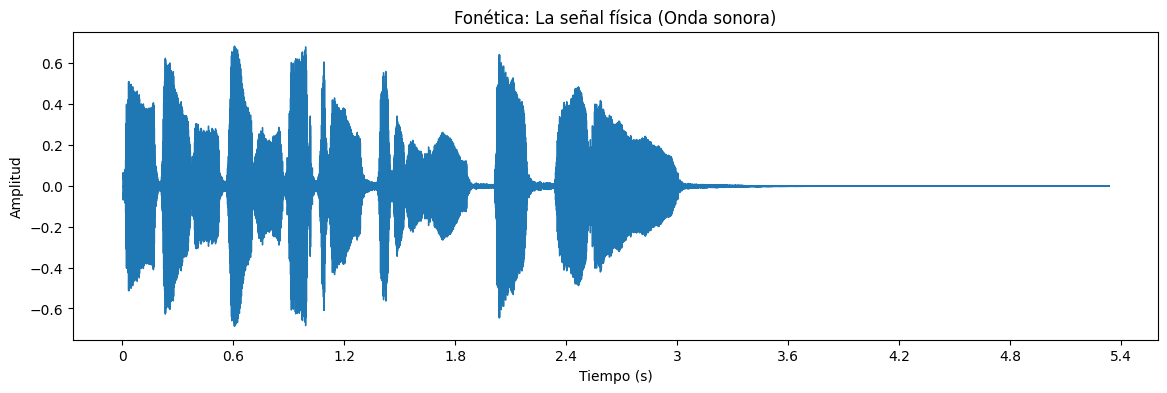

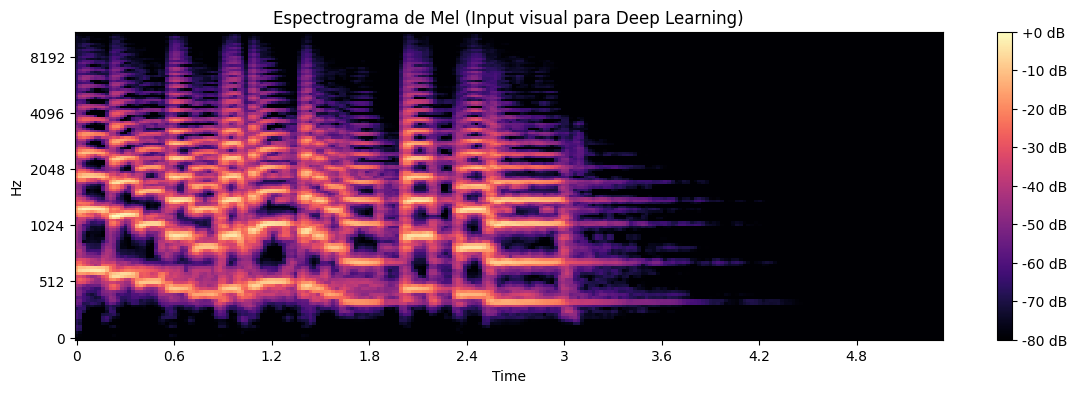

In [ ]:
# 1.1 Cargar un audio de ejemplo (usamos un sample de librosa)
filename = librosa.ex('trumpet') # Usamos trompeta como análogo simple de señal armónica
y, sr = librosa.load(filename)

# 1.2 Visualización de la Onda (Amplitud vs Tiempo)
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Fonética: La señal física (Onda sonora)')
plt.ylabel('Amplitud')
plt.xlabel('Tiempo (s)')
plt.show()

# 1.3 Espectrograma de Mel (Frecuencia vs Tiempo)
# Esto es lo que realmente "ven" las redes neuronales en Speech-to-Text
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)


plt.figure(figsize=(14, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel (Input visual para Deep Learning)')
plt.show()